# Library imports and setting file path

In [1]:
import os
import sys
import warnings
import pandas as pd
import geopandas as gpd

ROOT = os.path.abspath(".")
PY_SCRIPTS = os.path.join(ROOT, "py_scripts")
sys.path.insert(0, PY_SCRIPTS)

from parse_adjacency import parse_adjacency, load_adjacency
from parse_county_data import parse_county_data, load_county_data
from min_coverage import solve_min_coverage
from equitable_placement import solve_equitable
from helper_functions import STATE_FIPS_TO_NAME, plot_centers


SHP_PATH = os.path.join(ROOT, "county_data", "cb_2023_us_county_500k", "cb_2023_us_county_500k.shp")
ADJ_PATH = os.path.join(ROOT, "county_data", "county_adjacency.txt")
DEMO_PATH = os.path.join(ROOT, "county_data", "county_demographics.csv")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# User defines desired state of interest and k value for equitable placement model

In [2]:
STATE_NAME = "Arizona"
STATE_FIPS = {name: fips for fips, name in STATE_FIPS_TO_NAME.items()}[STATE_NAME]

k = 23

# Parse adjacency and county data

In [3]:
parse_adjacency(ADJ_PATH, STATE_FIPS)
parse_county_data(DEMO_PATH, STATE_FIPS)
adj = load_adjacency(STATE_FIPS)
cdata = load_county_data(STATE_FIPS)

# Load shapefile and filter to desired state

In [4]:
shp = gpd.read_file(SHP_PATH)
state_shp = shp[shp["STATEFP"] == STATE_FIPS]
state_shp = state_shp.to_crs(state_shp.estimate_utm_crs())

# Solve Minimum Coverage Problem

Set parameter Username
Set parameter LicenseID to value 2764175
Academic license - for non-commercial use only - expires 2027-01-13
Min coverage: 3 centers, objective 3.0, 0.0145s


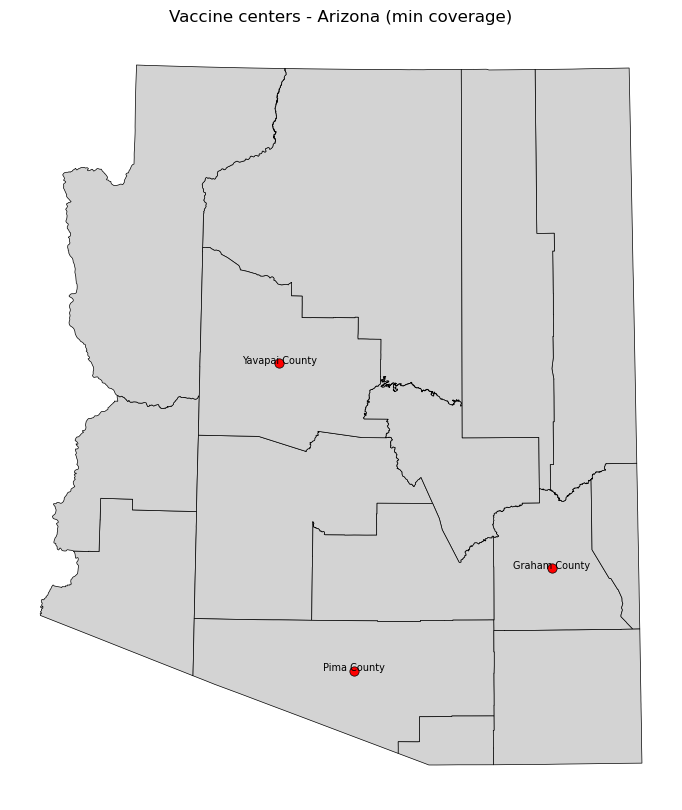

In [5]:
centers_a, obj_a, time_a = solve_min_coverage(adj, cdata)
print(f"Min coverage: {len(centers_a)} centers, objective {obj_a}, {time_a:.4f}s")
plot_centers(state_shp, cdata, centers_a, "min coverage")

In [6]:
df_a = pd.DataFrame(
    [
        {
            "FIPS": fips,
            "County": data["name"],
            "Population": data["population"],
            "Is_Center": fips in centers_a,
        }
        for fips, data in cdata.items()
    ]
)
display(df_a)

,FIPS,County,Population,Is_Center
0,04001,Apache County,64445,False
1,04003,Cochise County,126332,False
2,04005,Coconino County,144368,False
3,04007,Gila County,53801,False
4,04009,Graham County,40157,True
5,04011,Greenlee County,9312,False
6,04012,La Paz County,16711,False
7,04013,Maricopa County,4689558,False
8,04015,Mohave County,228102,False
9,04017,Navajo County,109946,False


# Solve Equitable Placement Problem

Equitable (k=23): 15 centers, objective 0.00, 0.0005s


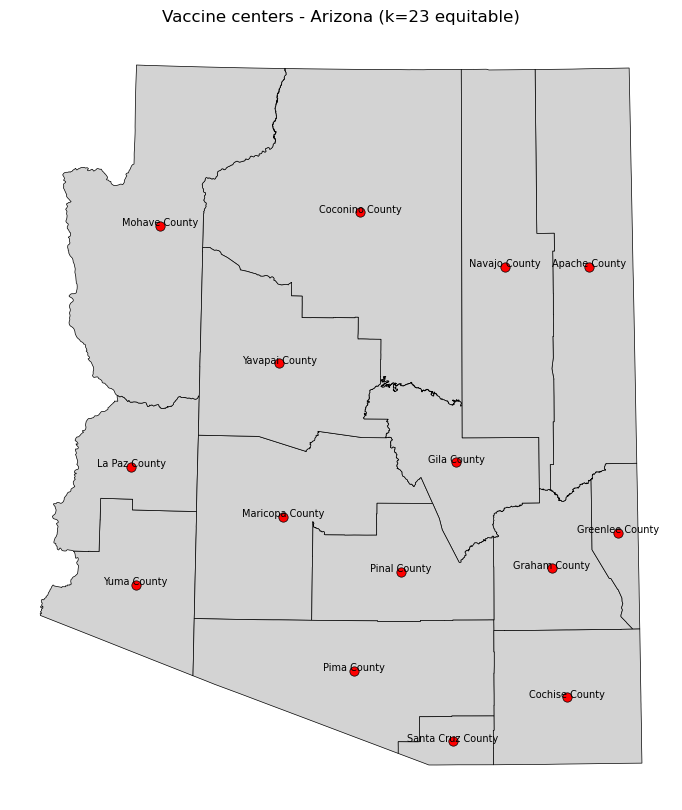

In [7]:
centers_b, obj_b, time_b, assigned = solve_equitable(cdata, k)
print(
    f"Equitable (k={k}): {len(centers_b)} centers, objective {obj_b:.2f}, {time_b:.4f}s"
)
plot_centers(state_shp, cdata, centers_b, f"k={k} equitable")

In [8]:
df_b = pd.DataFrame(
    [
        {
            "FIPS": fips,
            "County": data["name"],
            "Population": data["population"],
            "Is_Center": fips in centers_b,
            "Assigned_To": assigned.get(fips),
        }
        for fips, data in cdata.items()
    ]
)
display(df_b)

,FIPS,County,Population,Is_Center,Assigned_To
0,04001,Apache County,64445,True,04001
1,04003,Cochise County,126332,True,04003
2,04005,Coconino County,144368,True,04005
3,04007,Gila County,53801,True,04007
4,04009,Graham County,40157,True,04009
5,04011,Greenlee County,9312,True,04011
6,04012,La Paz County,16711,True,04012
7,04013,Maricopa County,4689558,True,04013
8,04015,Mohave County,228102,True,04015
9,04017,Navajo County,109946,True,04017
